# THESIS EoMT-DINOv3 Pretrained


In [1]:
%%capture

!pip install torch torchvision torchaudio
!pip install -U "transformers>=5.2.0" accelerate safetensors hf_xet
!pip install albumentations opencv-python pillow pandas scikit-learn tqdm


## Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from transformers import AutoImageProcessor, EomtDinov3ForUniversalSegmentation
import os
import zipfile
import random
import json
from pathlib import Path
from tqdm import tqdm


> Seeding


In [3]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)


## Import Dataset


- Unzip dataset


In [4]:
os.makedirs("/content/flopwd_data", exist_ok=True)

with zipfile.ZipFile("/content/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025).zip", "r") as zip_ref:
  zip_ref.extractall("/content/flopwd_data")


- Get Images


In [5]:
raw_images = sorted(list(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Raw_Images").glob("*")))
mask_images = sorted(list(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Segmentation_Masks").glob("*")))
labels_csv = Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Image_labels_Binary Classification Task.csv")
reg_csv = Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Mask_foreground_percentages_Regression Task.csv")


In [6]:
labels_df = pd.read_csv(labels_csv)
reg_df = pd.read_csv(reg_csv)


In [7]:
labels_df.head()


,image name,Presence of plastic waste?
0,img1.jpg,yes
1,img2.jpg,yes
2,img3.jpg,yes
3,img4.jpg,yes
4,img5.jpg,yes


In [8]:
reg_df.head()


,image name,plastic waste accumulation (in percentage)
0,img1.jpg,0.08
1,img2.jpg,0.03
2,img3.jpg,0.38
3,img4.jpg,0.20
4,img5.jpg,0.18


### Transform Dataset


In [9]:
labels_df = labels_df.rename(columns={
    "image name": "image_name",
    "Presence of plastic waste?": "presence"
})

reg_df = reg_df.rename(columns={
    "image name": "image_name",
    "plastic waste accumulation (in percentage)": "fg_pct"
})

df = labels_df.merge(reg_df, on="image_name", how="inner")

df["image_path"] = df["image_name"].apply(lambda x: str(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Raw_Images") / x))
df["mask_name"] = df["image_name"].str.replace(".jpg", "_mask.png", regex=False)
df["mask_path"] = df["mask_name"].apply(lambda x: str(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Segmentation_Masks") / x))

df["presence"] = df["presence"].astype(str).str.strip().str.lower()
df["has_plastic"] = (df["presence"] == "yes").astype(int)

df.head()


,image_name,presence,fg_pct,image_path,mask_name,mask_path,has_plastic
0,img1.jpg,yes,0.08,/content/flopwd_data/Dal Lake Floating Plastic...,img1_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
1,img2.jpg,yes,0.03,/content/flopwd_data/Dal Lake Floating Plastic...,img2_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
2,img3.jpg,yes,0.38,/content/flopwd_data/Dal Lake Floating Plastic...,img3_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
3,img4.jpg,yes,0.20,/content/flopwd_data/Dal Lake Floating Plastic...,img4_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
4,img5.jpg,yes,0.18,/content/flopwd_data/Dal Lake Floating Plastic...,img5_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1


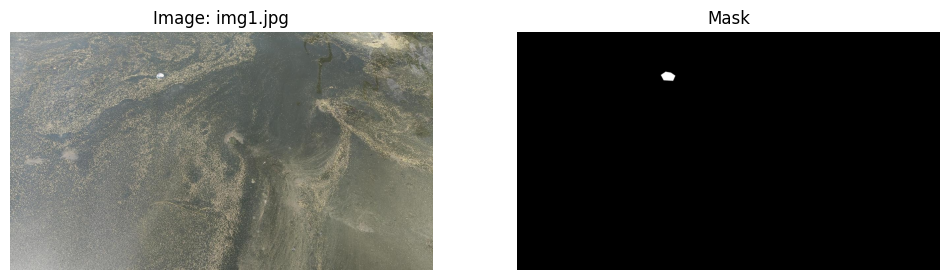

In [10]:
row = df.iloc[0]
image = cv2.imread(row["image_path"])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Image: {row['image_name']}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()


## Data Splitting (70:15:15)


In [11]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["has_plastic"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df["has_plastic"]
)


In [12]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))


Train: 1445
Val  : 256
Test : 301


## Data Preprocessing


### Image Augmentation


In [13]:
IMAGE_HEIGHT = 512
IMAGE_WIDTH = 512
BATCH_SIZE = 1
NUM_CLASSES = 2
GRAD_ACCUM_STEPS = 4
MODEL_ID = "tue-mps/eomt-dinov3-ade-semantic-large-512"


### Image Processor


In [14]:
processor = AutoImageProcessor.from_pretrained(MODEL_ID)

mean = tuple(getattr(processor, "image_mean", [0.485, 0.456, 0.406]))
std = tuple(getattr(processor, "image_std", [0.229, 0.224, 0.225]))

mean, std


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

In [15]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
    A.OneOf([
        A.ElasticTransform(alpha=1, sigma=50, p=0.5),
        A.GridDistortion(p=0.5),
    ], p=0.3),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.3),
    A.CoarseDropout(
        num_holes_range=(1, 8),
        hole_height_range=(16, 32),
        hole_width_range=(16, 32),
        p=0.3
    ),
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.Normalize(mean=mean, std=std, max_pixel_value=255.0),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.Normalize(mean=mean, std=std, max_pixel_value=255.0),
    ToTensorV2()
])


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### Image Preprocessing (Class & Dataloader)


In [16]:
class FloPWDDataset(Dataset):
  def __init__(self, dataframe, transforms=None):
    self.dataframe = dataframe
    self.transforms = transforms

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    row = self.dataframe.iloc[idx]

    image = cv2.imread(row["image_path"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    mask = (mask > 127).astype(np.uint8)

    if self.transforms:
      transformed = self.transforms(image=image, mask=mask)
      image = transformed["image"]
      mask = transformed["mask"]

    mask = mask.long()

    return image.float(), mask


In [17]:
train_dataset = FloPWDDataset(train_df, transforms=train_transform)
val_dataset = FloPWDDataset(val_df, transforms=val_transform)
test_dataset = FloPWDDataset(test_df, transforms=val_transform)


In [18]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


## Modelling


In [19]:
id2label = {
    0: "background",
    1: "plastic"
}

label2id = {
    "background": 0,
    "plastic": 1
}


In [20]:
%%capture

model = EomtDinov3ForUniversalSegmentation.from_pretrained(
    MODEL_ID,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `150`.
[transformers] EomtDinov3ForUniversalSegmentation LOAD REPORT from: tue-mps/eomt-dinov3-ade-semantic-large-512
Key                    | Status   |                                                                                           
-----------------------+----------+-------------------------------------------------------------------------------------------
class_predictor.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([151]) vs model:torch.Size([3])            
criterion.empty_weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([151]) vs model:torch.Size([3])            
class_predictor.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([151, 1024]) vs model:torch.Size([3, 1024])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


## Training


#### Training Hyperparameter


In [21]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEVICE


'cuda'

In [23]:
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Total parameters    : 314,796,035
Trainable parameters: 314,796,035


#### Loss Function


##### Pos Weight Estimation for Class Imbalance Handling


In [24]:
pos_pixels = 0
neg_pixels = 0

subset = train_df.sample(min(200, len(train_df)), random_state=42)

for _, row in subset.iterrows():
  mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
  mask = (mask > 127).astype(np.uint8)

  pos_pixels += mask.sum()
  neg_pixels += mask.size - mask.sum()

pos_weight = neg_pixels / max(pos_pixels, 1)

pos_weight

np.float64(17.441991871195814)

##### Cross Entropy


In [25]:
class_weights = torch.tensor([1.0, float(min(pos_weight, 50.0))], device=DEVICE)

class_weights

tensor([ 1.0000, 17.4420], device='cuda:0')

##### DICE


In [26]:
def dice_loss(semantic_probs, targets, smooth=1.0):
  probs = semantic_probs[:, 1, :, :]
  targets = targets.float()

  intersection = (probs * targets).sum(dim=(1, 2))
  union = probs.sum(dim=(1, 2)) + targets.sum(dim=(1, 2))

  dice = (2.0 * intersection + smooth) / (union + smooth)
  return 1.0 - dice.mean()

##### Combine


In [27]:
def ce_loss(semantic_probs, targets):
  log_probs = torch.log(semantic_probs.clamp(min=1e-6, max=1.0))
  return F.nll_loss(log_probs, targets, weight=class_weights)


def combined_loss(semantic_probs, targets, dice_weight=0.7, ce_weight=0.3):
  d_loss = dice_loss(semantic_probs, targets)
  c_loss = ce_loss(semantic_probs, targets)
  return dice_weight * d_loss + ce_weight * c_loss

#### Optimizer


In [28]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

#### Metric


In [29]:
def eomt_forward(model, images, target_size):
  outputs = model(pixel_values=images)

  class_logits = outputs.class_queries_logits
  mask_logits = outputs.masks_queries_logits

  class_probs = torch.softmax(class_logits, dim=-1)

  if class_probs.shape[-1] == NUM_CLASSES + 1:
    class_probs = class_probs[..., :-1]
  elif class_probs.shape[-1] > NUM_CLASSES:
    class_probs = class_probs[..., :NUM_CLASSES]

  mask_probs = torch.sigmoid(mask_logits)
  semantic_probs = torch.einsum("bqc,bqhw->bchw", class_probs, mask_probs)

  semantic_probs = F.interpolate(
      semantic_probs,
      size=target_size,
      mode="bilinear",
      align_corners=False
  )

  semantic_probs = semantic_probs / semantic_probs.sum(dim=1, keepdim=True).clamp_min(1e-6)
  return semantic_probs.clamp(min=1e-6, max=1.0)


def binarize_mask(prob_mask, threshold=0.5):
  return (prob_mask > threshold).float()

In [30]:
def compute_stats(preds, targets, eps=1e-7):
  preds = preds.float()
  targets = targets.float()

  tp = (preds * targets).sum(dim=(1, 2))
  fp = (preds * (1 - targets)).sum(dim=(1, 2))
  fn = ((1 - preds) * targets).sum(dim=(1, 2))
  tn = ((1 - preds) * (1 - targets)).sum(dim=(1, 2))

  foreground_iou = (tp + eps) / (tp + fp + fn + eps)
  background_iou = (tn + eps) / (tn + fp + fn + eps)
  miou = (foreground_iou + background_iou) / 2.0
  dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
  precision = (tp + eps) / (tp + fp + eps)
  recall = (tp + eps) / (tp + fn + eps)

  return {
      "iou": foreground_iou.mean().item(),
      "foreground_iou": foreground_iou.mean().item(),
      "background_iou": background_iou.mean().item(),
      "miou": miou.mean().item(),
      "dice": dice.mean().item(),
      "precision": precision.mean().item(),
      "recall": recall.mean().item()
  }

In [31]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0

    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(loader, desc="Training", leave=False)

    for step, (images, masks) in enumerate(pbar):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            semantic_probs = eomt_forward(model, images, target_size=(masks.shape[1], masks.shape[2]))
            loss = combined_loss(semantic_probs, masks)
            scaled_loss = loss / GRAD_ACCUM_STEPS

        scaler.scale(scaled_loss).backward()

        if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    return running_loss / len(loader)

In [32]:
def validate_one_epoch(model, loader, device, threshold=0.5):
    model.eval()

    running_loss = 0.0
    iou_scores = []
    foreground_iou_scores = []
    background_iou_scores = []
    miou_scores = []
    dice_scores = []
    precision_scores = []
    recall_scores = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validation", leave=False):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            semantic_probs = eomt_forward(model, images, target_size=(masks.shape[1], masks.shape[2]))
            loss = combined_loss(semantic_probs, masks)

            probs = semantic_probs[:, 1, :, :]
            preds = binarize_mask(probs, threshold=threshold)
            stats = compute_stats(preds, masks)

            running_loss += loss.item()
            iou_scores.append(stats["iou"])
            foreground_iou_scores.append(stats["foreground_iou"])
            background_iou_scores.append(stats["background_iou"])
            miou_scores.append(stats["miou"])
            dice_scores.append(stats["dice"])
            precision_scores.append(stats["precision"])
            recall_scores.append(stats["recall"])

    return {
        "loss": running_loss / len(loader),
        "iou": np.mean(iou_scores),
        "foreground_iou": np.mean(foreground_iou_scores),
        "background_iou": np.mean(background_iou_scores),
        "miou": np.mean(miou_scores),
        "dice": np.mean(dice_scores),
        "precision": np.mean(precision_scores),
        "recall": np.mean(recall_scores)
    }

In [33]:
def find_best_threshold(model, loader, device):
    thresholds = np.arange(0.10, 0.91, 0.05)
    best_threshold = 0.5
    best_dice = -1

    model.eval()

    all_probs = []
    all_masks = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Collecting val probs", leave=False):
            images = images.to(device)
            masks = masks.to(device)

            semantic_probs = eomt_forward(model, images, target_size=(masks.shape[1], masks.shape[2]))
            probs = semantic_probs[:, 1, :, :].cpu()

            all_probs.append(probs)
            all_masks.append(masks.cpu().float())

    all_probs = torch.cat(all_probs, dim=0)
    all_masks = torch.cat(all_masks, dim=0)

    for threshold in thresholds:
        preds = (all_probs > threshold).float()
        stats = compute_stats(preds, all_masks)
        if stats["dice"] > best_dice:
            best_dice = stats["dice"]
            best_threshold = threshold

    return best_threshold, best_dice

#### Training


In [37]:
EPOCHS = 10
PATIENCES = 5

In [38]:
best_val_dice = -1
best_model_path = "/content/best_flopwd_eomt_dinov3_pretrained.pth"

history = []
counter = 0

In [39]:
for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)

    best_threshold, _ = find_best_threshold(model, val_loader, DEVICE)
    val_metrics = validate_one_epoch(model, val_loader, DEVICE, threshold=best_threshold)

    print(f"Train Loss        : {train_loss:.4f}")
    print(f"Val Loss          : {val_metrics['loss']:.4f}")
    print(f"Val Foreground IoU: {val_metrics['foreground_iou']:.4f}")
    print(f"Val Background IoU: {val_metrics['background_iou']:.4f}")
    print(f"Val mIoU          : {val_metrics['miou']:.4f}")
    print(f"Val Dice          : {val_metrics['dice']:.4f}")
    print(f"Val Precision     : {val_metrics['precision']:.4f}")
    print(f"Val Recall        : {val_metrics['recall']:.4f}")
    print(f"Best Threshold    : {best_threshold:.2f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_iou": val_metrics["iou"],
        "val_foreground_iou": val_metrics["foreground_iou"],
        "val_background_iou": val_metrics["background_iou"],
        "val_miou": val_metrics["miou"],
        "val_dice": val_metrics["dice"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "best_threshold": float(best_threshold)
    })

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")
        counter = 0
    else:
        counter += 1
        print(f"No improvement. Patience counter: {counter}/{PATIENCES}")

    if counter >= PATIENCES:
        print("Early stopping triggered.")
        break


Epoch [1/10]


Train Loss        : 0.4868
Val Loss          : 0.3676
Val Foreground IoU: 0.5520
Val Background IoU: 0.9687
Val mIoU          : 0.7604
Val Dice          : 0.6516
Val Precision     : 0.7027
Val Recall        : 0.7519
Best Threshold    : 0.90
Best model saved.

Epoch [2/10]


Train Loss        : 0.3452
Val Loss          : 0.3364
Val Foreground IoU: 0.6119
Val Background IoU: 0.9629
Val mIoU          : 0.7874
Val Dice          : 0.7062
Val Precision     : 0.7322
Val Recall        : 0.8165
Best Threshold    : 0.90
Best model saved.

Epoch [3/10]


Train Loss        : 0.2999
Val Loss          : 0.3299
Val Foreground IoU: 0.5751
Val Background IoU: 0.9685
Val mIoU          : 0.7718
Val Dice          : 0.6757
Val Precision     : 0.6903
Val Recall        : 0.7997
Best Threshold    : 0.75
No improvement. Patience counter: 1/5

Epoch [4/10]


Train Loss        : 0.3110
Val Loss          : 0.2931
Val Foreground IoU: 0.6306
Val Background IoU: 0.9686
Val mIoU          : 0.7996
Val Dice          : 0.7288
Val Precision     : 0.7505
Val Recall        : 0.7990
Best Threshold    : 0.75
Best model saved.

Epoch [5/10]


...

Train Loss        : 0.2879
Val Loss          : 0.2914
Val Foreground IoU: 0.6443
Val Background IoU: 0.9681
Val mIoU          : 0.8062
Val Dice          : 0.7400
Val Precision     : 0.7759
Val Recall        : 0.8030
Best Threshold    : 0.90
Best model saved.

Epoch [7/10]


Train Loss        : 0.2935
Val Loss          : 0.2935
Val Foreground IoU: 0.6234
Val Background IoU: 0.9676
Val mIoU          : 0.7955
Val Dice          : 0.7239
Val Precision     : 0.7324
Val Recall        : 0.8049
Best Threshold    : 0.90
No improvement. Patience counter: 1/5

Epoch [8/10]


Train Loss        : 0.2882
Val Loss          : 0.3067
Val Foreground IoU: 0.6039
Val Background IoU: 0.9667
Val mIoU          : 0.7853
Val Dice          : 0.7061
Val Precision     : 0.7210
Val Recall        : 0.8036
Best Threshold    : 0.85
No improvement. Patience counter: 2/5

Epoch [9/10]


Train Loss        : 0.2795
Val Loss          : 0.3030
Val Foreground IoU: 0.6190
Val Background IoU: 0.9697
Val mIoU          : 0.7943
Val Dice          : 0.7205
Val Precision     : 0.7363
Val Recall        : 0.8065
Best Threshold    : 0.55
No improvement. Patience counter: 3/5

Epoch [10/10]


Train Loss        : 0.2735
Val Loss          : 0.2806
Val Foreground IoU: 0.6412
Val Background IoU: 0.9683
Val mIoU          : 0.8048
Val Dice          : 0.7390
Val Precision     : 0.7498
Val Recall        : 0.8143
Best Threshold    : 0.80
No improvement. Patience counter: 4/5


##### Training History


In [40]:
history_df = pd.DataFrame(history)
history_df.to_csv("/content/flopwd_eomt_dinov3_training_history.csv", index=False)
history_df.tail()

,epoch,train_loss,val_loss,val_iou,val_foreground_iou,val_background_iou,val_miou,val_dice,val_precision,val_recall,best_threshold
5,6,0.287915,0.291351,0.644258,0.644258,0.968125,0.806191,0.739958,0.775909,0.803026,0.90
6,7,0.293541,0.293505,0.623365,0.623365,0.967640,0.795503,0.723914,0.732407,0.804888,0.90
7,8,0.288243,0.306673,0.603921,0.603921,0.966713,0.785317,0.706094,0.721012,0.803586,0.85
8,9,0.279500,0.302987,0.618956,0.618956,0.969660,0.794308,0.720521,0.736265,0.806483,0.55
9,10,0.273535,0.280564,0.641212,0.641212,0.968324,0.804768,0.739033,0.749751,0.814266,0.80


##### Best Model


In [41]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

<All keys matched successfully>

##### Best Threshold


In [42]:
best_threshold, best_dice = find_best_threshold(model, val_loader, DEVICE)

#### Save Model


In [43]:
%%capture

save_dir = "/content/eomt-dinov3-plastic"
model.save_pretrained(save_dir)
processor.save_pretrained(save_dir)

with open(f"{save_dir}/training_metadata.json", "w") as f:
    json.dump({
        "best_threshold": float(best_threshold),
        "best_dice": float(best_dice),
        "model_id": MODEL_ID,
        "image_height": IMAGE_HEIGHT,
        "image_width": IMAGE_WIDTH,
        "num_classes": NUM_CLASSES,
        "label2id": label2id,
        "id2label": id2label
    }, f, indent=4)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

#### Evaluation


In [44]:
test_metrics = validate_one_epoch(model, test_loader, DEVICE, threshold=best_threshold)

for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

loss: 0.3121
iou: 0.6147
foreground_iou: 0.6147
background_iou: 0.9686
miou: 0.7917
dice: 0.7097
precision: 0.7551
recall: 0.7968


- Result


In [45]:
with open("/content/flopwd_eomt_dinov3_test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=4)

## Inferences


In [46]:
def denormalize_image(image_tensor, mean, std):
    image = image_tensor.permute(1, 2, 0).cpu().numpy()
    image = image * np.array(std) + np.array(mean)
    image = np.clip(image, 0, 1)
    return image

def show_predictions(model, dataset, device, threshold=0.5, num_samples=5):
    model.eval()
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    plt.figure(figsize=(15, num_samples * 5))

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask = dataset[idx]

            input_tensor = image.unsqueeze(0).to(device)
            semantic_probs = eomt_forward(model, input_tensor, target_size=(mask.shape[0], mask.shape[1]))
            probs = semantic_probs[:, 1, :, :]
            pred = (probs > threshold).float()

            image_np = denormalize_image(image, mean, std)
            mask_np = mask.cpu().numpy()
            pred_np = pred.squeeze().cpu().numpy()

            plt.subplot(num_samples, 3, i * 3 + 1)
            plt.imshow(image_np)
            plt.title("Image")
            plt.axis("off")

            plt.subplot(num_samples, 3, i * 3 + 2)
            plt.imshow(mask_np, cmap="gray")
            plt.title("Ground Truth")
            plt.axis("off")

            plt.subplot(num_samples, 3, i * 3 + 3)
            plt.imshow(pred_np, cmap="gray")
            plt.title("Prediction")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

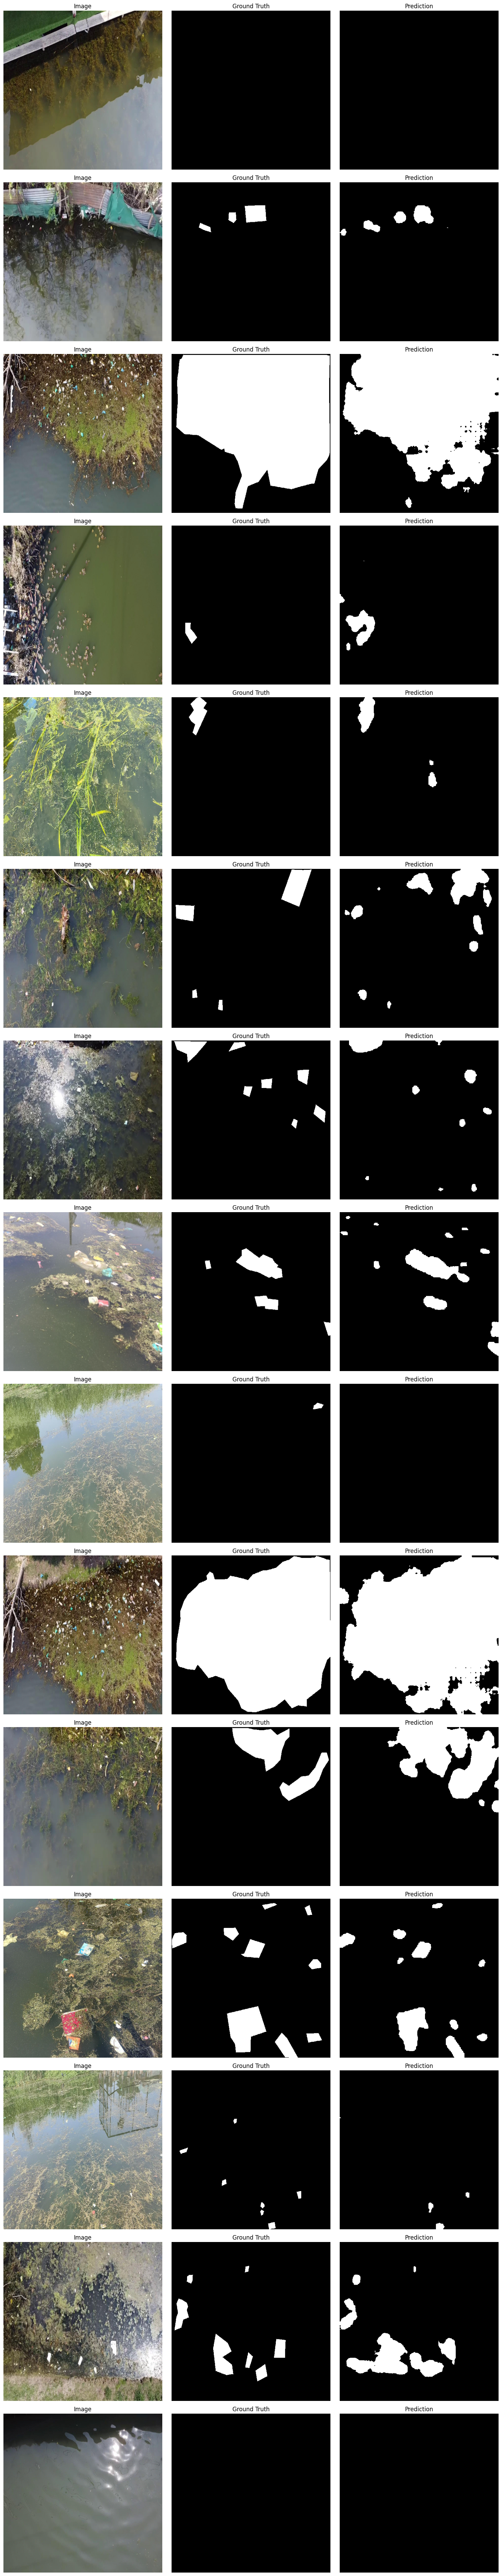

In [47]:
show_predictions(model, test_dataset, DEVICE, threshold=best_threshold, num_samples=15)

## Regression Percentage


In [48]:
def predict_regression_percentages(model, dataset, dataframe, device, threshold=0.5):
    model.eval()
    rows = []

    with torch.no_grad():
        for idx in tqdm(range(len(dataset)), desc="Regression percentage"):
            image, mask = dataset[idx]
            image_tensor = image.unsqueeze(0).to(device)

            semantic_probs = eomt_forward(model, image_tensor, target_size=(mask.shape[0], mask.shape[1]))
            probs = semantic_probs[0, 1].cpu()
            pred = (probs > threshold).float()

            row = dataframe.iloc[idx]
            actual_percentage = float(row["fg_pct"])
            mask_percentage = mask.float().mean().item() * 100.0
            predicted_percentage = pred.mean().item() * 100.0

            rows.append({
                "image_name": row["image_name"],
                "actual_regression_percentage": actual_percentage,
                "mask_percentage": mask_percentage,
                "predicted_regression_percentage": predicted_percentage,
                "absolute_error": abs(predicted_percentage - actual_percentage)
            })

    return pd.DataFrame(rows)

regression_df = predict_regression_percentages(
    model,
    test_dataset,
    test_df,
    DEVICE,
    threshold=best_threshold
)

regression_df.head(20)

Regression percentage: 100%|██████████| 301/301 [01:30<00:00,  3.31it/s]


,image_name,actual_regression_percentage,mask_percentage,predicted_regression_percentage,absolute_error
0,img1681.jpg,0.82,0.820160,0.549698,0.270302
1,img1514.jpg,13.20,13.210678,17.198563,3.998563
2,img356.jpg,0.00,0.000000,0.616837,0.616837
3,img1141.jpg,1.86,1.866531,1.301956,0.558044
4,img1564.jpg,0.86,0.866318,0.891876,0.031876
5,img1518.jpg,8.68,8.675766,17.707062,9.027062
6,img1337.jpg,18.13,18.128204,21.554184,3.424184
7,img1984.jpg,3.09,3.088379,4.840088,1.750088
8,img1992.jpg,0.24,0.236893,0.990295,0.750295
9,img1850.jpg,4.02,4.021835,6.690216,2.670216


In [49]:
mae = regression_df["absolute_error"].mean()
rmse = np.sqrt(((regression_df["predicted_regression_percentage"] - regression_df["actual_regression_percentage"]) ** 2).mean())

print(f"Regression MAE : {mae:.4f}%")
print(f"Regression RMSE: {rmse:.4f}%")

regression_df.to_csv("/content/flopwd_eomt_dinov3_regression_percentages.csv", index=False)
regression_df.describe()

Regression MAE : 1.4264%
Regression RMSE: 2.9366%


,actual_regression_percentage,mask_percentage,predicted_regression_percentage,absolute_error
count,301.000000,301.000000,301.000000,301.000000
mean,5.313920,5.368483,5.983552,1.426372
std,11.567161,11.575443,11.508985,2.571176
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.033624
50%,1.000000,0.994110,1.221085,0.372089
75%,4.990000,4.993439,6.576157,1.483630
max,74.470000,74.482727,77.047348,14.070710


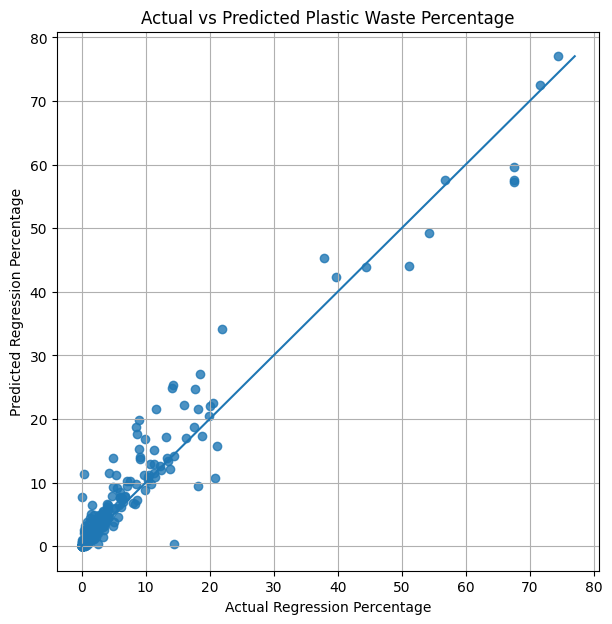

In [50]:
plt.figure(figsize=(7, 7))
plt.scatter(
    regression_df["actual_regression_percentage"],
    regression_df["predicted_regression_percentage"],
    alpha=0.8
)

min_value = min(
    regression_df["actual_regression_percentage"].min(),
    regression_df["predicted_regression_percentage"].min()
)
max_value = max(
    regression_df["actual_regression_percentage"].max(),
    regression_df["predicted_regression_percentage"].max()
)

plt.plot([min_value, max_value], [min_value, max_value])
plt.xlabel("Actual Regression Percentage")
plt.ylabel("Predicted Regression Percentage")
plt.title("Actual vs Predicted Plastic Waste Percentage")
plt.grid(True)
plt.show()